# EGNN experiments with balanced 3% subsets

This notebook runs the stable EGNN with:

- invariant bottleneck
- **pairwise-distance reconstruction only**
- rotation consistency loss
- **no contrastive loss**
- **balanced subsampling** so that the selected phases have the **same number of samples**
- only **3% of each phase** is used before balancing

It produces results for:

1. **fcc / liquid / hcp**
2. **fcc / liquid**
3. **fcc / hcp**

The balancing rule is:

- first draw `3%` from each selected phase
- then reduce every selected phase to the **same count**, equal to the smallest of those sampled counts

This keeps the classes symmetric for each experiment.


In [26]:
# Imports
import math
import copy
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [27]:
# Global configuration
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

DATA_DIR = Path(".")
ALL_PHASES = ["fcc", "hcp", "liquid"]

LABEL_MAP_GLOBAL = {"fcc": 0, "hcp": 1, "liquid": 2}
LABEL_COLORS_GLOBAL = {"fcc": "tab:blue", "hcp": "tab:orange", "liquid": "tab:green"}

# data usage
SUBSAMPLE_FRAC = 0.1  # 10%
BALANCE_CLASSES = True

# model hyperparameters (stable version)
# Model and optimizer
LATENT_DIM = 2
OUT_DIM    = 12 * 11 // 2

LR = 2e-4          # instead of 2e-3
LAMBDA_INV = 0.1   # instead of 1.0
FEAT_DIM = 48      # instead of 96
N_EPOCHS = 30

BATCH_SIZE = 256
WEIGHT_DECAY = 1e-6

# stability
UPDATE_COORDS = True     # set False if unstable
COORD_SCALE   = 0.05
GRAD_CLIP     = 1.0



device: cuda


## Data loading

In [28]:
def load_vec_dist(npz_path):
    arr = np.load(npz_path, allow_pickle=True)["vec_dist"]

    if arr.ndim == 3 and arr.shape[2] == 3:
        return arr.astype(np.float32)

    if arr.ndim == 2 and arr.shape[1] % 3 == 0:
        n_neigh = arr.shape[1] // 3
        return arr.reshape(arr.shape[0], n_neigh, 3).astype(np.float32)

    raise ValueError(f"Unexpected vec_dist shape in {npz_path}: {arr.shape}")


all_X_by_phase = {}
for phase in ALL_PHASES:
    f = DATA_DIR / phase / "particle_data.npz"
    if not f.exists():
        raise FileNotFoundError(f"Could not find {f.resolve()}")
    X_phase = load_vec_dist(f)
    all_X_by_phase[phase] = X_phase
    print(f"{phase:>6s}: {X_phase.shape}")


   fcc: (180300, 12, 3)
   hcp: (180300, 12, 3)
liquid: (90300, 12, 3)


## Helper functions

In [29]:
def balanced_subsample_by_phase(X_by_phase, selected_phases, frac=0.1, seed=7, balance=True):
    rng = np.random.default_rng(seed)

    sampled = {}
    sampled_counts = {}

    for phase in selected_phases:
        Xp = X_by_phase[phase]
        n = len(Xp)
        n_sub = max(1, int(round(frac * n)))
        idx = rng.choice(n, size=n_sub, replace=False)
        sampled[phase] = Xp[idx]
        sampled_counts[phase] = n_sub

    if balance:
        n_bal = min(sampled_counts.values())
    else:
        n_bal = None

    all_X = []
    all_y = []

    label_map = {phase: i for i, phase in enumerate(selected_phases)}
    label_names = {i: phase for i, phase in enumerate(selected_phases)}
    label_colors = {i: LABEL_COLORS_GLOBAL[phase] for i, phase in enumerate(selected_phases)}

    for phase in selected_phases:
        Xp = sampled[phase]
        if balance:
            idx = rng.choice(len(Xp), size=n_bal, replace=False)
            Xp = Xp[idx]

        yp = np.full(len(Xp), label_map[phase], dtype=np.int64)
        all_X.append(Xp)
        all_y.append(yp)

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)

    return X, y, label_map, label_names, label_colors, sampled_counts, n_bal


def global_scale_coords(X):
    radii = np.linalg.norm(X, axis=-1).reshape(-1)
    scale = np.median(radii)
    return X / scale, scale


class NeighbourhoodDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_fully_connected_edges(n_nodes):
    senders, receivers = [], []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                senders.append(i)
                receivers.append(j)
    return torch.tensor([senders, receivers], dtype=torch.long)


def pairwise_dist_upper(x):
    dmat = torch.cdist(x, x, p=2)
    iu = torch.triu_indices(dmat.shape[1], dmat.shape[2], offset=1, device=dmat.device)
    return dmat[:, iu[0], iu[1]]


def random_rotation_matrix(batch_size, device):
    u1 = torch.rand(batch_size, device=device)
    u2 = torch.rand(batch_size, device=device)
    u3 = torch.rand(batch_size, device=device)

    q1 = torch.sqrt(1 - u1) * torch.sin(2 * math.pi * u2)
    q2 = torch.sqrt(1 - u1) * torch.cos(2 * math.pi * u2)
    q3 = torch.sqrt(u1) * torch.sin(2 * math.pi * u3)
    q4 = torch.sqrt(u1) * torch.cos(2 * math.pi * u3)

    R = torch.zeros(batch_size, 3, 3, device=device)
    R[:, 0, 0] = 1 - 2 * (q3**2 + q4**2)
    R[:, 0, 1] = 2 * (q2*q3 - q1*q4)
    R[:, 0, 2] = 2 * (q2*q4 + q1*q3)

    R[:, 1, 0] = 2 * (q2*q3 + q1*q4)
    R[:, 1, 1] = 1 - 2 * (q2**2 + q4**2)
    R[:, 1, 2] = 2 * (q3*q4 - q1*q2)

    R[:, 2, 0] = 2 * (q2*q4 - q1*q3)
    R[:, 2, 1] = 2 * (q3*q4 + q1*q2)
    R[:, 2, 2] = 1 - 2 * (q2**2 + q3**2)
    return R


def apply_random_rotation(x):
    R = random_rotation_matrix(x.shape[0], x.device)
    return torch.einsum("bij,bnj->bni", R, x)


## Model

In [30]:
class MLP(nn.Module):
    def __init__(self, dims, act=nn.SiLU, final_act=False):
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2 or final_act:
                layers.append(act())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EGNNLayer(nn.Module):
    def __init__(self, feat_dim, hidden_dim=64, update_coords=True, coord_scale=0.05):
        super().__init__()
        self.edge_mlp = MLP([2 * feat_dim + 1, hidden_dim, hidden_dim, hidden_dim])
        self.coord_mlp = MLP([hidden_dim, hidden_dim, 1])
        self.node_mlp  = MLP([feat_dim + hidden_dim, hidden_dim, feat_dim])

        self.update_coords = update_coords
        self.coord_scale = coord_scale

    def forward(self, h, x, edge_index):
        row, col = edge_index

        hi = h[:, row, :]
        hj = h[:, col, :]

        x_i = x[:, row, :]
        x_j = x[:, col, :]
        rel = x_i - x_j
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)

        m_in = torch.cat([hi, hj, dist2], dim=-1)
        m_ij = self.edge_mlp(m_in)

        if self.update_coords:
            coord_coeff = torch.tanh(self.coord_mlp(m_ij))
            trans = rel * coord_coeff

            B, N, _ = x.shape
            agg_trans = torch.zeros(B, N, 3, device=x.device, dtype=x.dtype)
            for b in range(B):
                agg_trans[b].index_add_(0, row, trans[b])

            x = x + self.coord_scale * agg_trans / (N - 1)

        H = m_ij.shape[-1]
        B, N, _ = h.shape
        agg_m = torch.zeros(B, N, H, device=h.device, dtype=h.dtype)
        for b in range(B):
            agg_m[b].index_add_(0, row, m_ij[b])

        h = h + self.node_mlp(torch.cat([h, agg_m], dim=-1))
        return h, x


class EGNNEncoder(nn.Module):
    def __init__(self, n_layers=2, feat_dim=48, latent_dim=3, update_coords=True, coord_scale=0.05):
        super().__init__()
        self.node_embed = nn.Linear(1, feat_dim)
        self.layers = nn.ModuleList([
            EGNNLayer(
                feat_dim=feat_dim,
                hidden_dim=feat_dim,
                update_coords=update_coords,
                coord_scale=coord_scale
            )
            for _ in range(n_layers)
        ])
        self.to_latent = MLP([feat_dim, feat_dim, feat_dim, latent_dim])

    def forward(self, x, edge_index):
        B, N, _ = x.shape
        h = torch.ones(B, N, 1, device=x.device)
        h = self.node_embed(h)

        for layer in self.layers:
            h, x = layer(h, x, edge_index)

        pooled = h.mean(dim=1)
        z_inv = self.to_latent(pooled)
        return z_inv, h, x


class DistDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, n_points):
        super().__init__()
        dist_out = n_points * (n_points - 1) // 2
        self.dist_head = MLP([latent_dim, hidden_dim, hidden_dim, hidden_dim, dist_out])

    def forward(self, z):
        return self.dist_head(z)


class InvariantEGNNDistAE(nn.Module):
    def __init__(self, n_layers=2, feat_dim=48, latent_dim=3, n_points=12, update_coords=True, coord_scale=0.05):
        super().__init__()
        self.encoder = EGNNEncoder(
            n_layers=n_layers,
            feat_dim=feat_dim,
            latent_dim=latent_dim,
            update_coords=update_coords,
            coord_scale=coord_scale
        )
        self.decoder = DistDecoder(
            latent_dim=latent_dim,
            hidden_dim=feat_dim,
            n_points=n_points
        )

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)[0]

    def forward(self, x, edge_index):
        z_inv, h, x_upd = self.encoder(x, edge_index)
        pred_dist = self.decoder(z_inv)
        return pred_dist, z_inv


## Experiment runner

In [ ]:
def evaluate_model(model, loader, edge_index):
    model.eval()
    total_loss = total_dist = total_inv = 0.0
    total_n = 0

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)

            target_dist = pairwise_dist_upper(xb)
            pred_dist, z = model(xb, edge_index)

            xb_rot = apply_random_rotation(xb)
            z_rot = model.encode(xb_rot, edge_index)

            loss_dist = F.smooth_l1_loss(pred_dist, target_dist)
            loss_inv  = F.mse_loss(z, z_rot)

            loss = loss_dist + LAMBDA_INV * loss_inv

            b = xb.shape[0]
            total_loss += loss.item() * b
            total_dist += loss_dist.item() * b
            total_inv  += loss_inv.item() * b
            total_n += b

    return {
        "loss": total_loss / total_n,
        "dist": total_dist / total_n,
        "inv": total_inv / total_n,
    }


def encode_numpy(model, X_np, edge_index, batch_size=512):
    model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
            z = model.encode(xb, edge_index)
            zs.append(z.cpu().numpy())
    return np.concatenate(zs, axis=0)


def plot_pairwise_latent_panels(z_val, y_val, label_names, label_colors, title):
    if z_val.shape[1] < 3:
        raise ValueError("Need latent_dim >= 3 for pairwise latent panels.")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    pairs = [(0, 1), (0, 2), (1, 2)]

    for ax, (i, j) in zip(axes, pairs):
        for lab in np.unique(y_val):
            mask = (y_val == lab)
            ax.scatter(
                z_val[mask, i], z_val[mask, j],
                s=10, alpha=0.25,
                color=label_colors[lab],
                label=label_names[lab] if (i, j) == (0, 1) else None
            )
        ax.set_xlabel(f"z{i+1}")
        ax.set_ylabel(f"z{j+1}")
        ax.grid(alpha=0.2)

    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_pca_latent(z_val, y_val, label_names, label_colors, title):
    z2 = PCA(n_components=2).fit_transform(z_val)
    plt.figure(figsize=(6, 5))
    for lab in np.unique(y_val):
        mask = (y_val == lab)
        plt.scatter(
            z2[mask, 0], z2[mask, 1],
            s=10, alpha=0.25,
            color=label_colors[lab],
            label=label_names[lab]
        )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_linear_probe(z_train, y_train, z_val, y_val, label_names, title):
    probe = LogisticRegression(max_iter=5000)
    probe.fit(z_train, y_train)
    y_pred = probe.predict(z_val)

    present_labels = sorted(np.unique(y_train))
    target_names = [label_names[i] for i in present_labels]

    print(title)
    print(classification_report(y_val, y_pred, labels=present_labels, target_names=target_names))

    cm = confusion_matrix(y_val, y_pred, labels=present_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()


def run_experiment(selected_phases, name):
    print("\n" + "=" * 80)
    print(f"Running experiment: {name}")
    print("=" * 80)

    X, y, label_map, label_names, label_colors, sampled_counts, n_bal = balanced_subsample_by_phase(
        all_X_by_phase,
        selected_phases=selected_phases,
        frac=SUBSAMPLE_FRAC,
        seed=SEED,
        balance=BALANCE_CLASSES
    )

    print("sampled counts before balancing:", sampled_counts)
    if BALANCE_CLASSES:
        print("Balanced count per selected phase:", n_bal)

    X_scaled, global_scale = global_scale_coords(X)
    print("Global scale used:", global_scale)

    idx_all = np.arange(len(X_scaled))
    idx_train, idx_val = train_test_split(
        idx_all,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    X_train = X_scaled[idx_train]
    X_val   = X_scaled[idx_val]
    y_train = y[idx_train]
    y_val   = y[idx_val]

    print("train:", X_train.shape, y_train.shape)
    print("val  :", X_val.shape, y_val.shape)

    train_ds = NeighbourhoodDataset(X_train, y_train)
    val_ds   = NeighbourhoodDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    n_points = X_train.shape[1]
    edge_index = make_fully_connected_edges(n_points).to(device)

    model = InvariantEGNNDistAE(
        n_layers=N_LAYERS,
        feat_dim=FEAT_DIM,
        latent_dim=LATENT_DIM,
        n_points=n_points,
        update_coords=UPDATE_COORDS,
        coord_scale=COORD_SCALE
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    history = {
        "train_loss": [], "train_dist": [], "train_inv": [],
        "val_loss": [],   "val_dist": [],   "val_inv": []
    }

    best_state = None
    best_val = float("inf")

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        total_loss = total_dist = total_inv = 0.0
        total_n = 0

        for xb, _ in train_loader:
            xb = xb.to(device)

            target_dist = pairwise_dist_upper(xb)
            pred_dist, z = model(xb, edge_index)

            xb_rot = apply_random_rotation(xb)
            z_rot = model.encode(xb_rot, edge_index)

            loss_dist = F.smooth_l1_loss(pred_dist, target_dist)
            loss_inv  = F.mse_loss(z, z_rot)
            loss = loss_dist + LAMBDA_INV * loss_inv

            if not torch.isfinite(loss):
                print("Non-finite loss encountered, skipping batch")
                optimizer.zero_grad()
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            b = xb.shape[0]
            total_loss += loss.item() * b
            total_dist += loss_dist.item() * b
            total_inv  += loss_inv.item() * b
            total_n += b

        train_stats = {
            "loss": total_loss / total_n,
            "dist": total_dist / total_n,
            "inv": total_inv / total_n,
        }
        val_stats = evaluate_model(model, val_loader, edge_index)

        for key in ["loss", "dist", "inv"]:
            history[f"train_{key}"].append(train_stats[key])
            history[f"val_{key}"].append(val_stats[key])

        if val_stats["loss"] < best_val:
            best_val = val_stats["loss"]
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 5 == 0 or epoch == N_EPOCHS:
            print(
                f"Epoch {epoch:03d} | "
                f"train: loss={train_stats['loss']:.5f}, dist={train_stats['dist']:.5f}, inv={train_stats['inv']:.5f} | "
                f"val: loss={val_stats['loss']:.5f}, dist={val_stats['dist']:.5f}, inv={val_stats['inv']:.5f}"
            )

    model.load_state_dict(best_state)
    print("Loaded best model with val loss:", best_val)

    plt.figure(figsize=(10, 5))
    plt.plot(history["train_loss"], label="train total")
    plt.plot(history["val_loss"], label="val total")
    plt.plot(history["train_dist"], "--", label="train dist")
    plt.plot(history["val_dist"], "--", label="val dist")
    plt.plot(history["train_inv"], ":", label="train inv")
    plt.plot(history["val_inv"], ":", label="val inv")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Training history: {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    z_train = encode_numpy(model, X_train, edge_index)
    z_val   = encode_numpy(model, X_val, edge_index)

    print("z_train shape:", z_train.shape)
    print("z_val shape  :", z_val.shape)

    xb = torch.tensor(X_val[:min(256, len(X_val))], dtype=torch.float32, device=device)
    xb_rot = apply_random_rotation(xb)
    with torch.no_grad():
        z0 = model.encode(xb, edge_index)
        z1 = model.encode(xb_rot, edge_index)
    delta = (z0 - z1).norm(dim=1).cpu().numpy()

    print("mean ||z - z_rot||:", delta.mean())
    print("median ||z - z_rot||:", np.median(delta))

    plt.figure(figsize=(5, 4))
    plt.hist(delta, bins=40)
    plt.xlabel(r"$\|z-z_{rot}\|$")
    plt.ylabel("count")
    plt.title(f"Rotation-invariance check: {name}")
    plt.tight_layout()
    plt.show()

    if LATENT_DIM >= 3:
        plot_pairwise_latent_panels(z_val, y_val, label_names, label_colors, f"Pairwise latent panels: {name}")

    plot_pca_latent(z_val, y_val, label_names, label_colors, f"PCA of EGNN latent: {name}")

    means = {lab: z_val[y_val == lab].mean(axis=0) for lab in np.unique(y_val)}
    for lab in means:
        print(f"{label_names[lab]} centroid:", means[lab])
    for a in means:
        for b in means:
            if a < b:
                d = np.linalg.norm(means[a] - means[b])
                print(f"{label_names[a]} vs {label_names[b]} centroid distance: {d:.4f}")

    run_linear_probe(z_train, y_train, z_val, y_val, label_names, f"Linear probe on EGNN latent: {name}")

    return {
        "model": model,
        "history": history,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "z_train": z_train,
        "z_val": z_val,
        "label_names": label_names,
        "label_colors": label_colors,
        "sampled_counts": sampled_counts,
        "balanced_count": n_bal,
    }


## Run the three requested experiments


Running experiment: fcc / liquid / hcp
3% sampled counts before balancing: {'fcc': 18030, 'liquid': 9030, 'hcp': 18030}
Balanced count per selected phase: 9030
Global scale used: 1.0627185
train: (21672, 12, 3) (21672,)
val  : (5418, 12, 3) (5418,)
Epoch 001 | train: loss=0.75288, dist=0.75288, inv=0.00000 | val: loss=0.27721, dist=0.27721, inv=0.00000
Epoch 005 | train: loss=0.07332, dist=0.07332, inv=0.00000 | val: loss=0.07360, dist=0.07360, inv=0.00000
Epoch 010 | train: loss=0.07181, dist=0.07181, inv=0.00000 | val: loss=0.07206, dist=0.07206, inv=0.00000
Epoch 015 | train: loss=0.07178, dist=0.07178, inv=0.00000 | val: loss=0.07204, dist=0.07204, inv=0.00000
Epoch 020 | train: loss=0.07179, dist=0.07179, inv=0.00000 | val: loss=0.07208, dist=0.07208, inv=0.00000
Epoch 025 | train: loss=0.07178, dist=0.07178, inv=0.00000 | val: loss=0.07202, dist=0.07202, inv=0.00000
Epoch 030 | train: loss=0.07177, dist=0.07177, inv=0.00000 | val: loss=0.07204, dist=0.07204, inv=0.00000
Loaded b

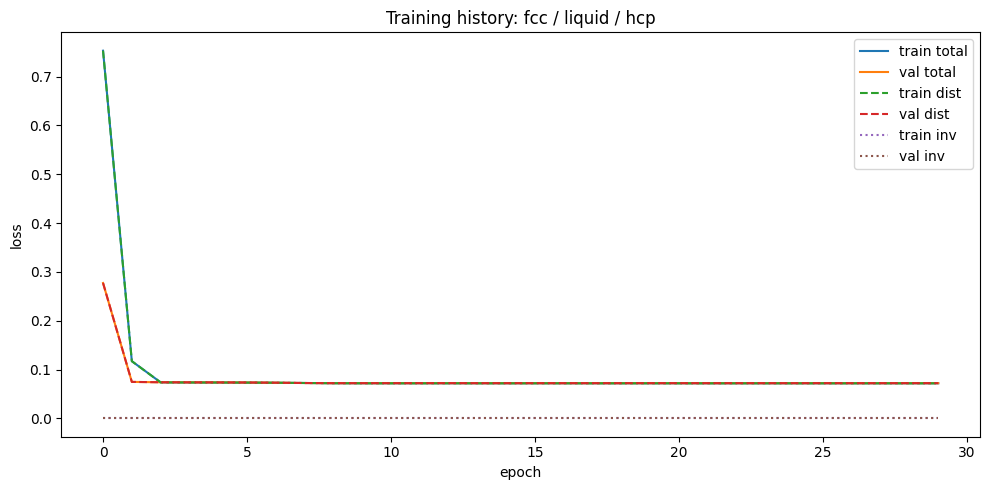

z_train shape: (21672, 2)
z_val shape  : (5418, 2)
mean ||z - z_rot||: 1.2312747e-06
median ||z - z_rot||: 1.0662403e-06


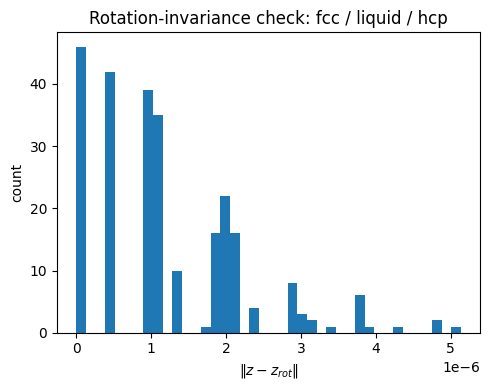

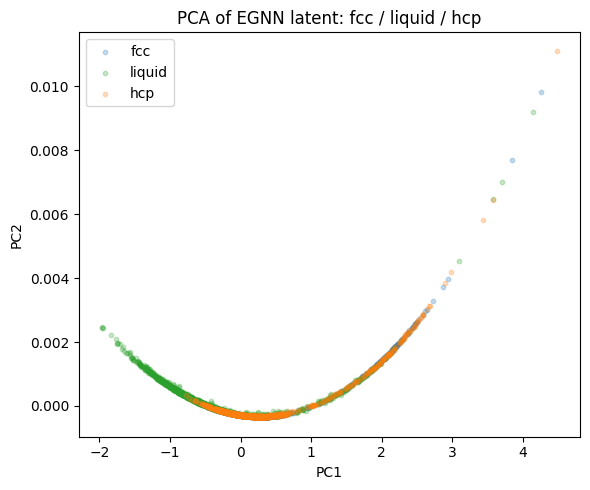

fcc centroid: [ -5.1096487 -14.163798 ]
liquid centroid: [ -5.3412275 -14.7883835]
hcp centroid: [ -5.1139917 -14.175413 ]
fcc vs liquid centroid distance: 0.6661
fcc vs hcp centroid distance: 0.0124
liquid vs hcp centroid distance: 0.6537
Linear probe on EGNN latent: fcc / liquid / hcp
              precision    recall  f1-score   support

         fcc       0.43      0.30      0.36      1806
      liquid       0.68      0.81      0.74      1806
         hcp       0.46      0.51      0.48      1806

    accuracy                           0.54      5418
   macro avg       0.52      0.54      0.53      5418
weighted avg       0.52      0.54      0.53      5418



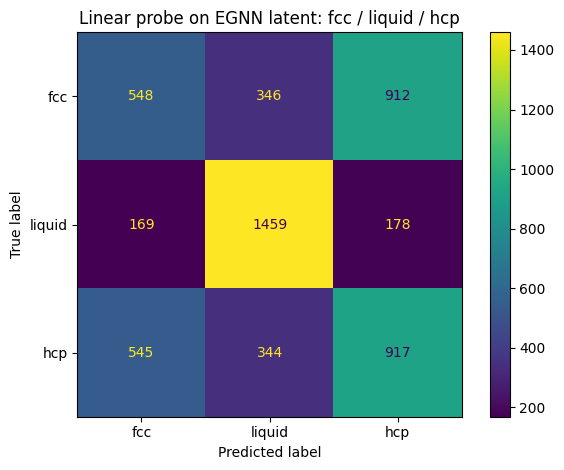

In [32]:
results_3class = run_experiment(["fcc", "liquid", "hcp"], "fcc / liquid / hcp")



Running experiment: fcc / liquid
3% sampled counts before balancing: {'fcc': 18030, 'liquid': 9030}
Balanced count per selected phase: 9030
Global scale used: 1.0668412
train: (14448, 12, 3) (14448,)
val  : (3612, 12, 3) (3612,)
Epoch 001 | train: loss=0.88852, dist=0.88852, inv=0.00000 | val: loss=0.55169, dist=0.55169, inv=0.00000
Epoch 005 | train: loss=0.07484, dist=0.07484, inv=0.00000 | val: loss=0.07452, dist=0.07452, inv=0.00000
Epoch 010 | train: loss=0.07429, dist=0.07429, inv=0.00000 | val: loss=0.07397, dist=0.07397, inv=0.00000
Epoch 015 | train: loss=0.07286, dist=0.07286, inv=0.00000 | val: loss=0.07276, dist=0.07276, inv=0.00000
Epoch 020 | train: loss=0.07287, dist=0.07287, inv=0.00000 | val: loss=0.07277, dist=0.07277, inv=0.00000
Epoch 025 | train: loss=0.07286, dist=0.07286, inv=0.00000 | val: loss=0.07274, dist=0.07274, inv=0.00000
Epoch 030 | train: loss=0.07286, dist=0.07286, inv=0.00000 | val: loss=0.07277, dist=0.07277, inv=0.00000
Loaded best model with val l

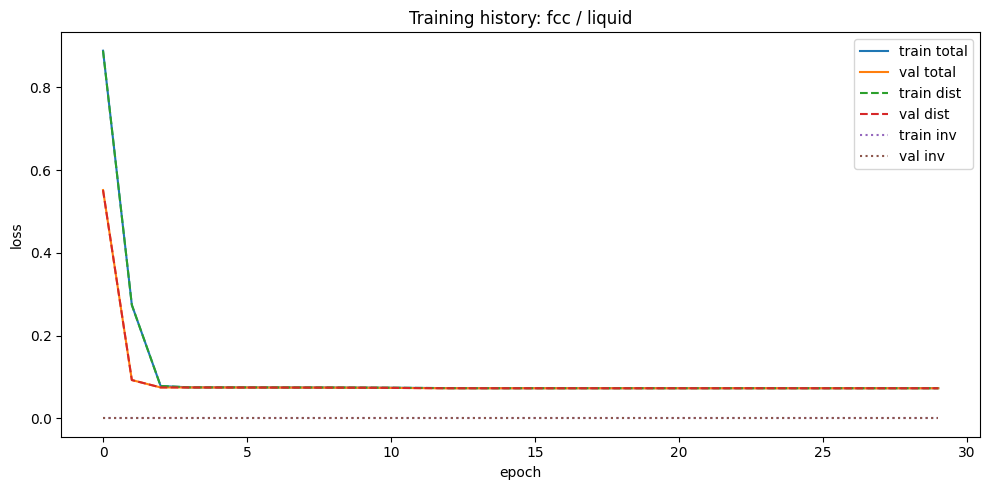

z_train shape: (14448, 2)
z_val shape  : (3612, 2)
mean ||z - z_rot||: 1.1639127e-06
median ||z - z_rot||: 9.536743e-07


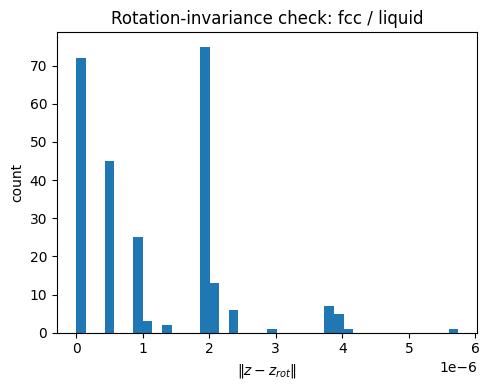

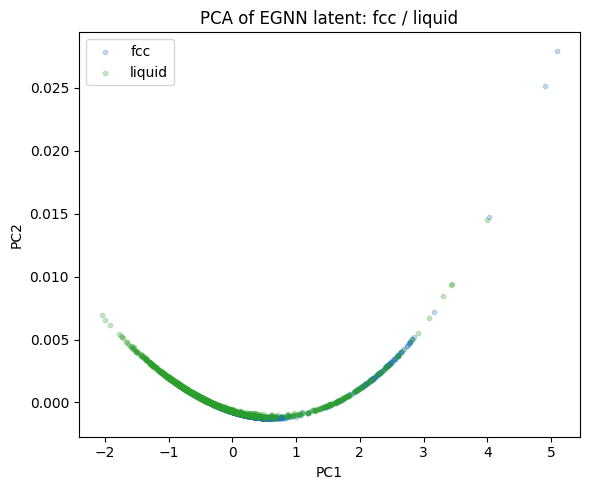

fcc centroid: [-16.177197   4.622183]
liquid centroid: [-16.818901   4.809821]
fcc vs liquid centroid distance: 0.6686
Linear probe on EGNN latent: fcc / liquid
              precision    recall  f1-score   support

         fcc       0.80      0.81      0.80      1806
      liquid       0.81      0.80      0.80      1806

    accuracy                           0.80      3612
   macro avg       0.80      0.80      0.80      3612
weighted avg       0.80      0.80      0.80      3612



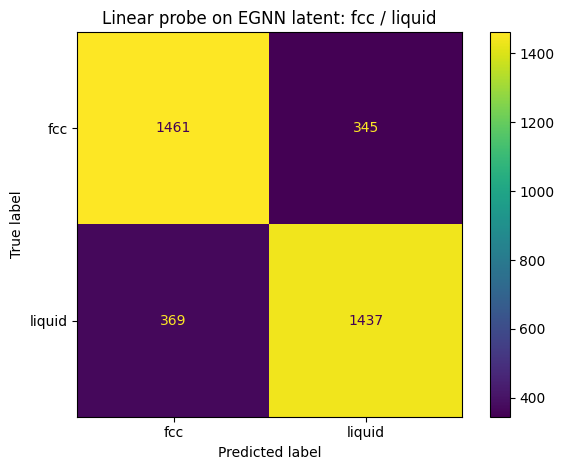

In [33]:
results_fcc_liq = run_experiment(["fcc", "liquid"], "fcc / liquid")



Running experiment: fcc / hcp
3% sampled counts before balancing: {'fcc': 18030, 'hcp': 18030}
Balanced count per selected phase: 18030
Global scale used: 1.0564528
train: (28848, 12, 3) (28848,)
val  : (7212, 12, 3) (7212,)
Epoch 001 | train: loss=0.61887, dist=0.61887, inv=0.00000 | val: loss=0.11291, dist=0.11291, inv=0.00000
Epoch 005 | train: loss=0.07038, dist=0.07038, inv=0.00000 | val: loss=0.07052, dist=0.07052, inv=0.00000
Epoch 010 | train: loss=0.06908, dist=0.06908, inv=0.00000 | val: loss=0.06922, dist=0.06922, inv=0.00000
Epoch 015 | train: loss=0.06909, dist=0.06909, inv=0.00000 | val: loss=0.06922, dist=0.06922, inv=0.00000
Epoch 020 | train: loss=0.06910, dist=0.06910, inv=0.00000 | val: loss=0.06925, dist=0.06925, inv=0.00000
Epoch 025 | train: loss=0.06909, dist=0.06909, inv=0.00000 | val: loss=0.06924, dist=0.06924, inv=0.00000
Epoch 030 | train: loss=0.06910, dist=0.06910, inv=0.00000 | val: loss=0.06922, dist=0.06922, inv=0.00000
Loaded best model with val loss:

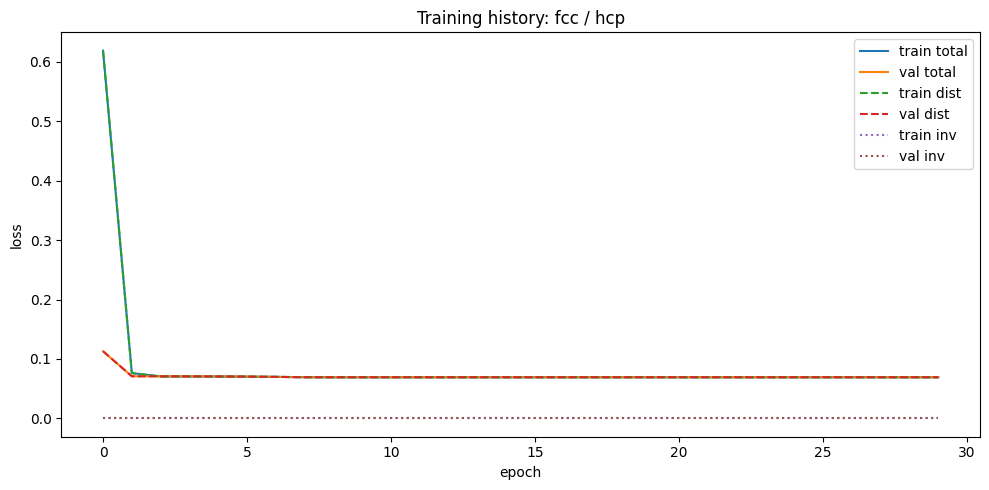

z_train shape: (28848, 2)
z_val shape  : (7212, 2)
mean ||z - z_rot||: 1.2547082e-06
median ||z - z_rot||: 7.1525574e-07


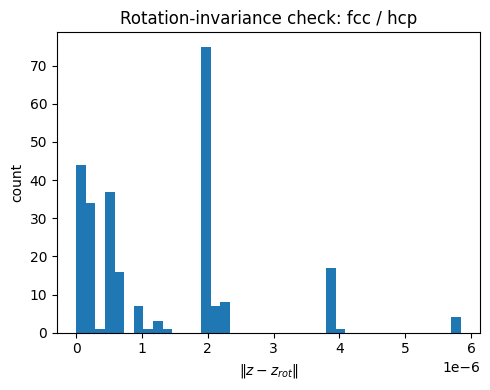

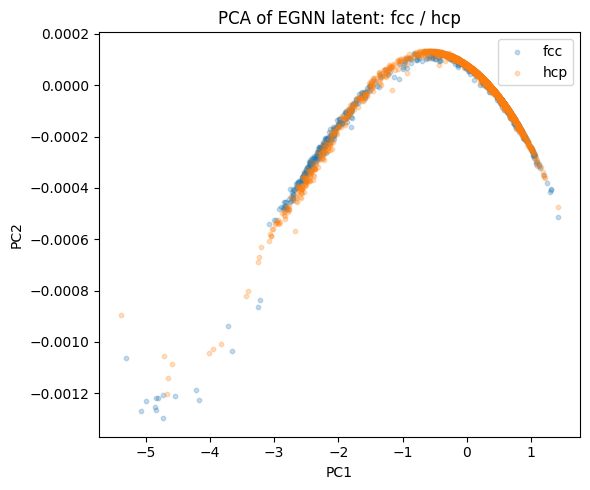

fcc centroid: [ 2.4795225 18.104856 ]
hcp centroid: [ 2.48182  18.121447]
fcc vs hcp centroid distance: 0.0167
Linear probe on EGNN latent: fcc / hcp
              precision    recall  f1-score   support

         fcc       0.00      0.00      0.00      3606
         hcp       0.50      1.00      0.67      3606

    accuracy                           0.50      7212
   macro avg       0.25      0.50      0.33      7212
weighted avg       0.25      0.50      0.33      7212



/home/carina/python/comp-phys/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carina/python/comp-phys/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carina/python/comp-phys/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

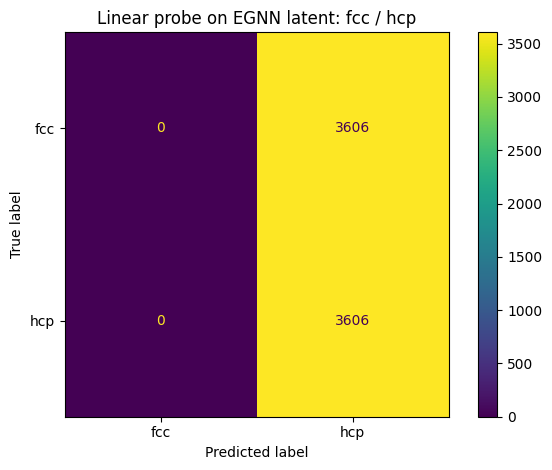

In [34]:
results_fcc_hcp = run_experiment(["fcc", "hcp"], "fcc / hcp")
